# Tutorial: JAX Flow Matching Environment

A compact notebook version of the 2D Gaussian-mixture flow-matching example.

## Gaussian Mixture Setup

We use a standard normal source distribution and a five-mode isotropic Gaussian mixture target.

In [ ]:
from pathlib import Path
from tqdm import tqdm
import jax
import jax.numpy as jnp

from flow_matching.distributions import make_symmetric_gmm_2d
from flow_matching.models import MLPVectorField
from flow_matching.plot import (
    plot_analytic_flow_path,
    plot_conditional_probability_path,
    plot_learned_flow_path,
    plot_training_loss,
)
from flow_matching.train import create_train_state, train_step

output_dir = Path("../outputs/notebook")
output_dir.mkdir(parents=True, exist_ok=True)
key = jax.random.PRNGKey(0)
gmm = make_symmetric_gmm_2d(nmodes=5, std=1.0, scale=10.0)
gmm.means


Array([[10.       ,  0.       ],
       [ 3.0901697,  9.510566 ],
       [-8.090171 ,  5.877852 ],
       [-8.09017  , -5.8778534],
       [ 3.0901713, -9.510565 ]], dtype=float32)

## Conditional Probability Path

Condition on one target sample and inspect Gaussian path samples over time.

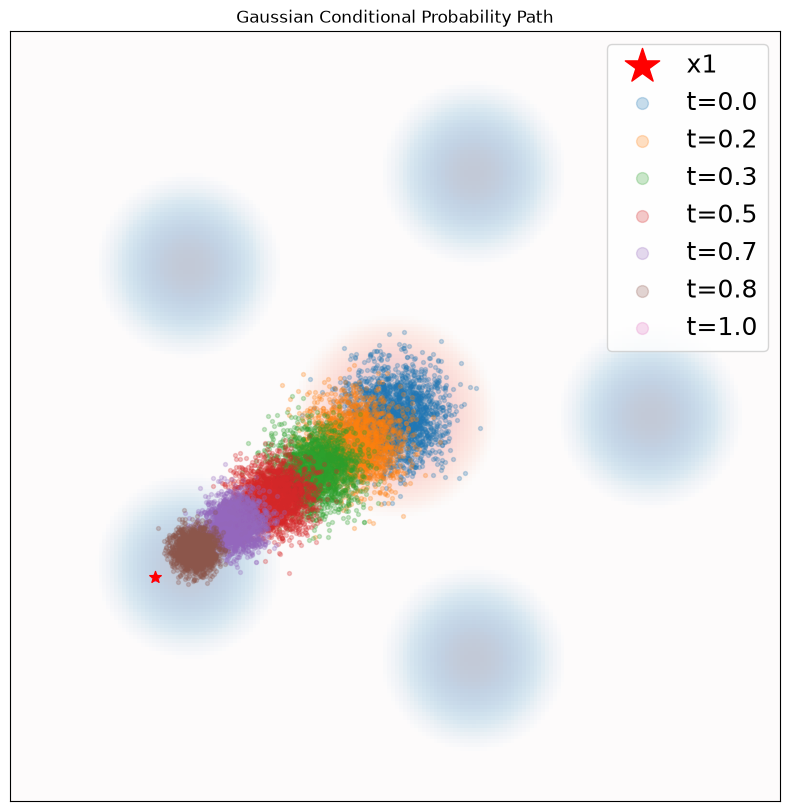

In [ ]:
plot_conditional_probability_path(
    key,
    gmm,
    # output=output_dir / "conditional_probability_path.png",
    num_samples=2_000,
)


## Analytic Conditional ODE

The analytic conditional vector field should move source samples toward the fixed conditioning point.

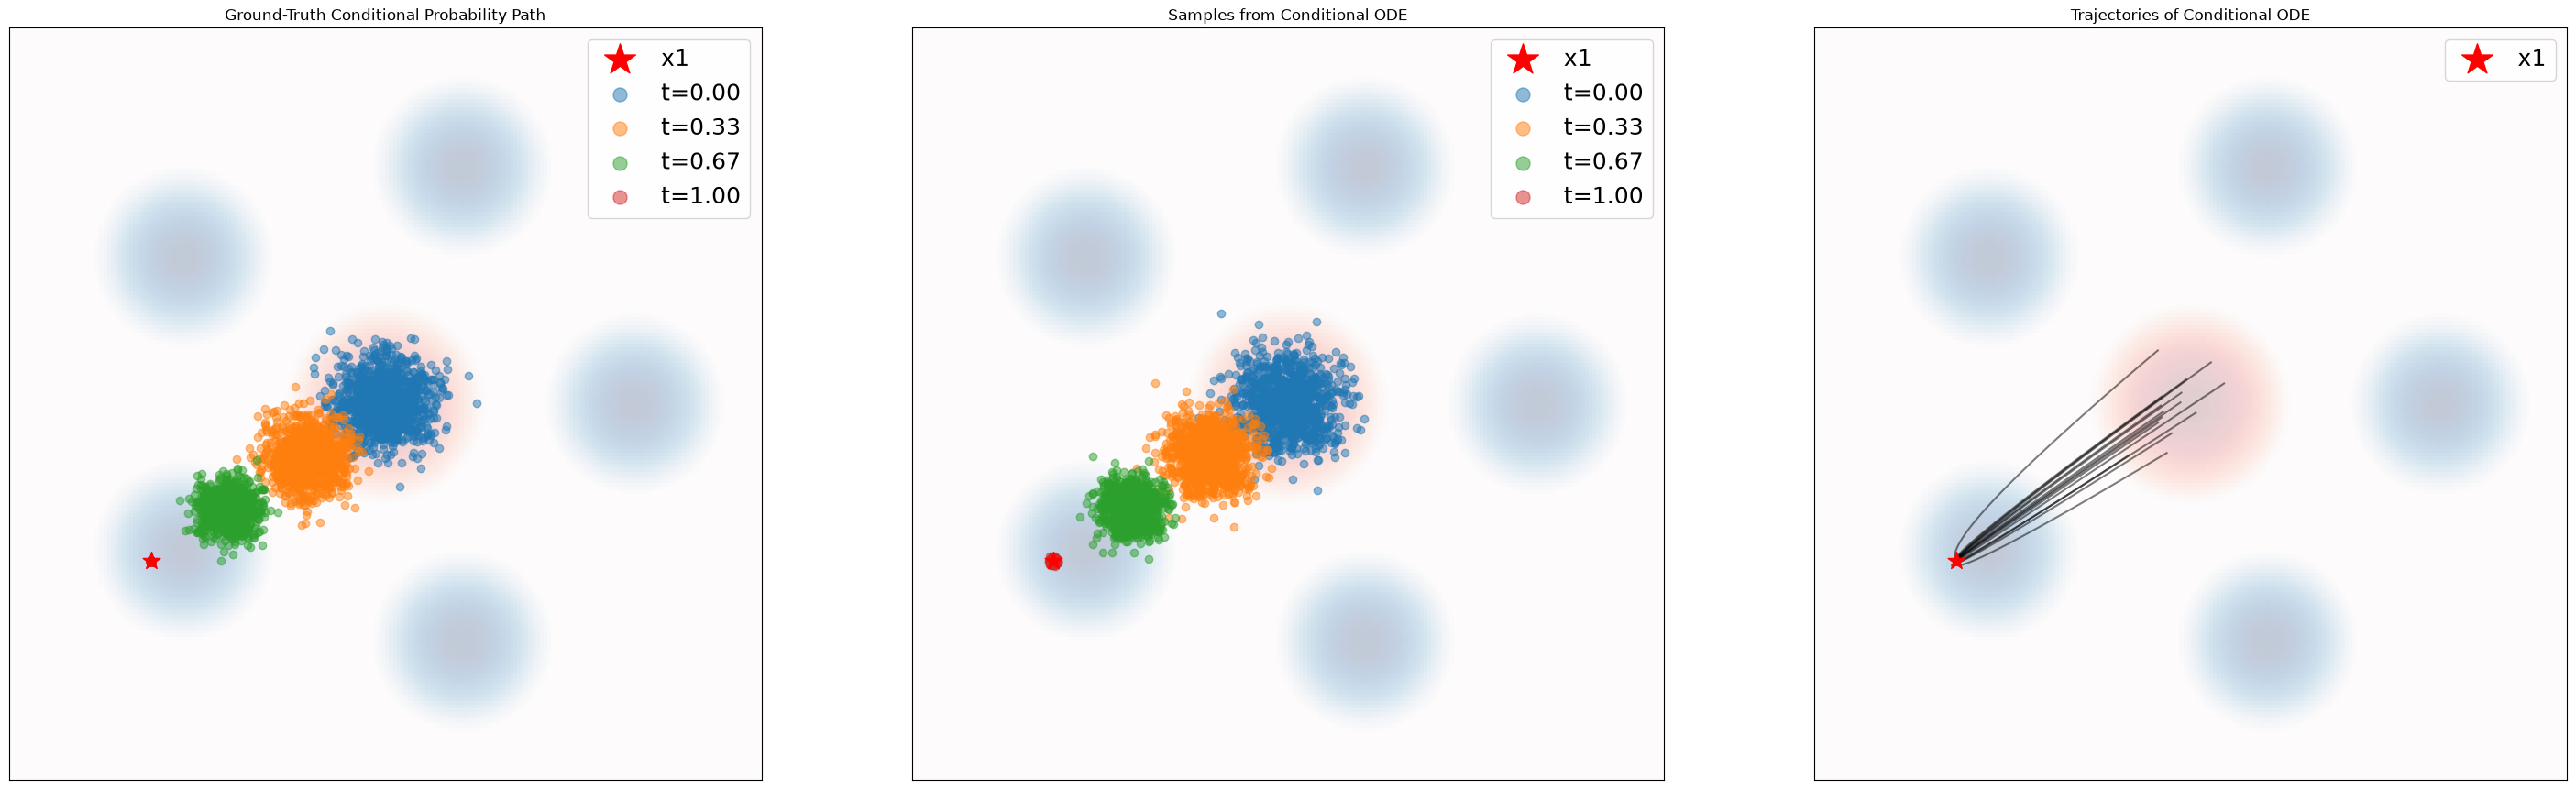

In [ ]:
plot_analytic_flow_path(
    key,
    gmm,
    #   output=output_dir / "analytic_flow_path.png",
    num_samples=1_000,
    num_timesteps=100,
)


## Train A Marginal Vector Field

Train the small Flax MLP on the conditional flow-matching objective.

In [ ]:
model = MLPVectorField(hidden_dims=(64, 64, 64, 64))
key, init_key = jax.random.split(key)
state = create_train_state(init_key, model, learning_rate=1e-3)
losses = []
for _ in tqdm(range(500)):
    key, step_key = jax.random.split(key)
    state, loss = train_step(state, step_key, gmm, batch_size=512)
    losses.append(loss)
losses = jnp.asarray(losses)
losses[-1]


100%|██████████| 500/500 [00:00<00:00, 781.82it/s] 


Array(11.220759, dtype=float32)

## Training Loss And Learned Flow

The learned flow plot integrates the model-predicted vector field from source samples.

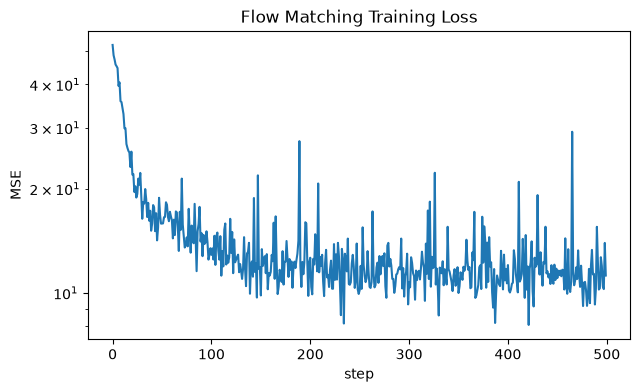

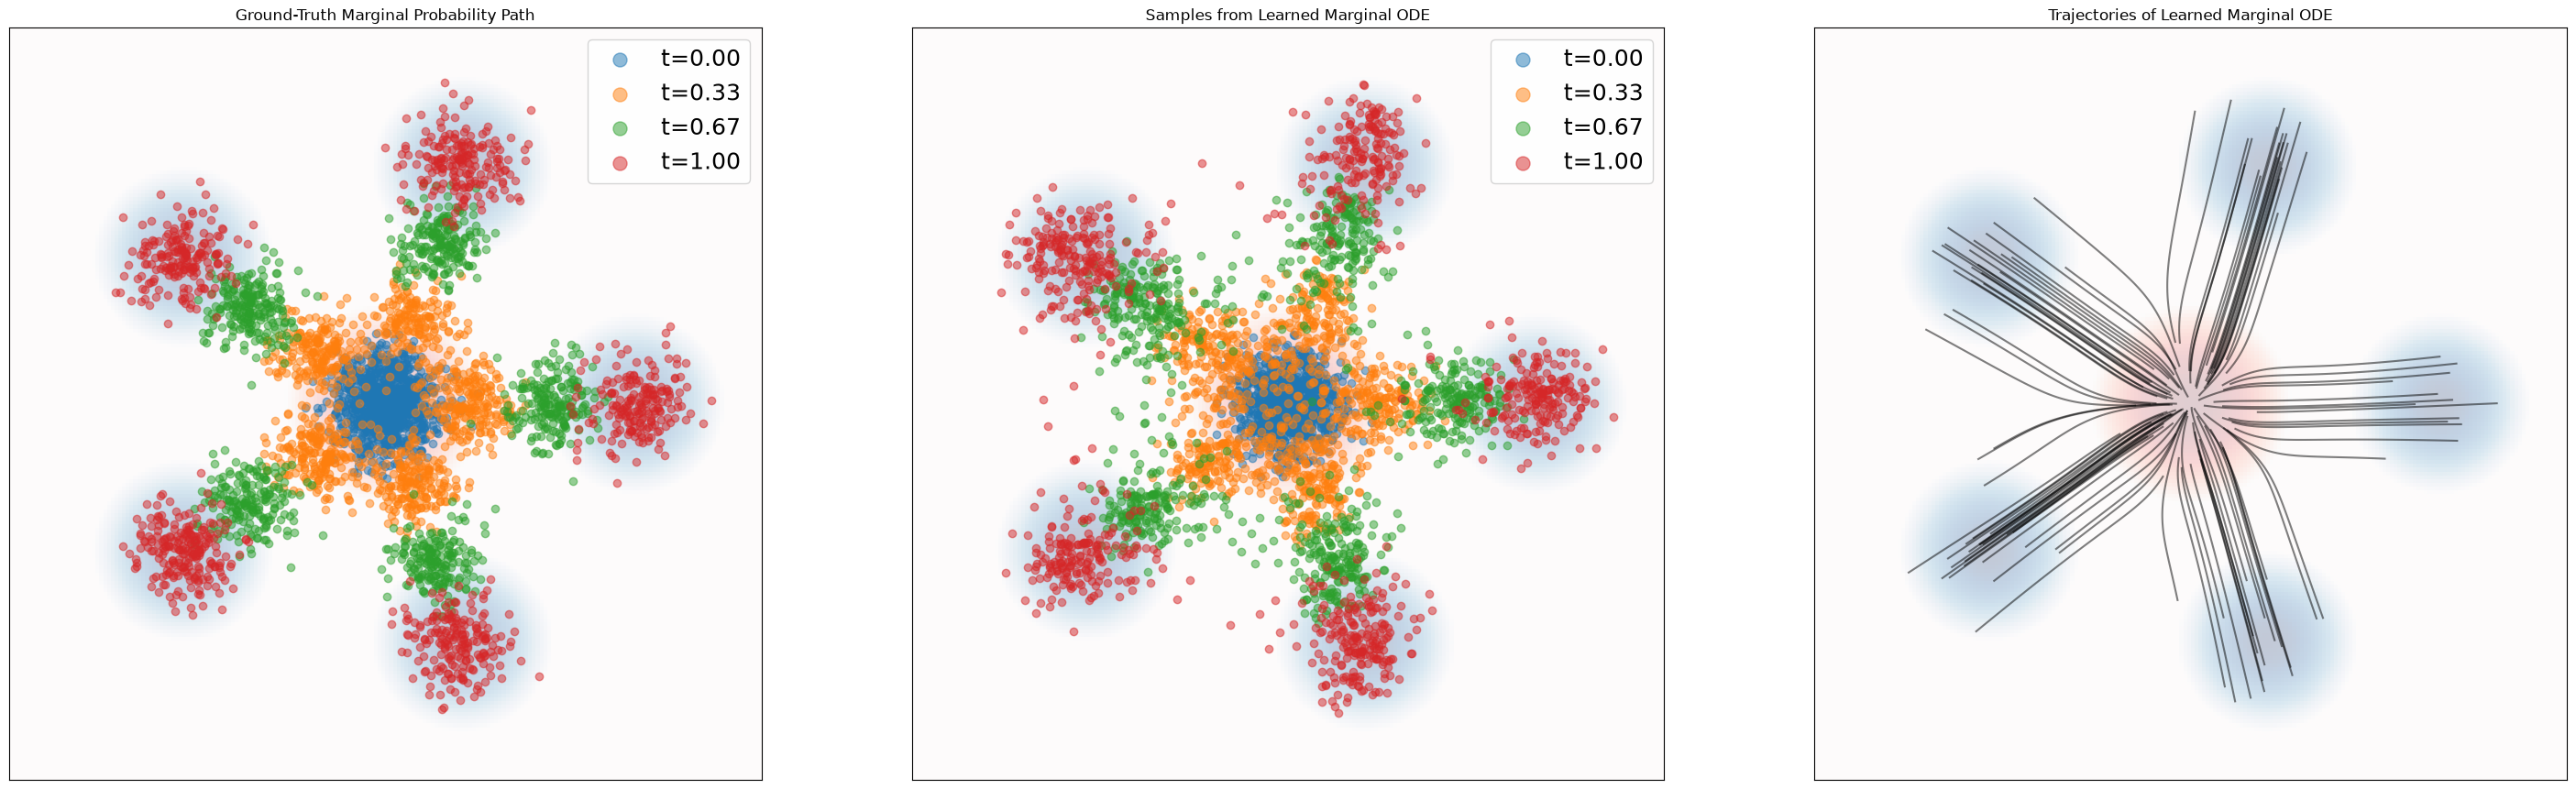

In [ ]:
plot_training_loss(
    losses,
    # output=output_dir / "training_loss.png"
)
plot_learned_flow_path(
    key,
    gmm,
    state.apply_fn,
    state.params,
    # output=output_dir / "learned_flow_path.png",
    num_samples=1_000,
    num_timesteps=100,
)
